# Day 2 - Feature Engineering & Exploratory Data Analysis (EDA)

**Intern:** Ahmed Ali

**Internship:** ProSensia AI/ML Internship

## Objective

The objective of this notebook is to perform Feature Engineering and Exploratory Data Analysis (EDA) on the cleaned Titanic dataset generated in Day 1. The notebook demonstrates data preprocessing, feature creation, categorical encoding, and visualization to better understand the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from pathlib import Path

# Get project root directory
BASE_DIR = Path.cwd().parent

# Path to Day 1 cleaned dataset
file_path = BASE_DIR / "Day 1" / "cleaned_titanic.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1.0,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1.0,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0.0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1.0,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0.0,0,373450,8.0500,Unknown,S


## Dataset Overview

In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp          float64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [4]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.0,891,891.000000,891,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,148,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",Male,NaN,NaN,NaN,347082,NaN,Unknown,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,687,646
mean,446.000000,0.383838,2.308642,NaN,NaN,29.039282,0.426487,0.0,NaN,24.046813,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,12.072074,0.708246,0.0,NaN,20.481625,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,2.500000,0.000000,0.0,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.0,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.0,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.0,NaN,31.000000,NaN,NaN


## Feature Engineering

Feature Engineering is the process of creating or transforming existing data into a format that improves analysis and machine learning. In this notebook, categorical variables will be converted into numerical form using One-Hot Encoding.

In [5]:
print("Checking for datetime columns...")

datetime_columns = df.select_dtypes(include=["datetime64"]).columns

if len(datetime_columns) == 0:
    print("No datetime column found in this dataset.")
else:
    print(datetime_columns)

Checking for datetime columns...
No datetime column found in this dataset.


### Datetime Feature Extraction

The cleaned Titanic dataset does not contain any datetime columns. Therefore, features such as day, month, and weekday cannot be extracted. This step is not applicable for this dataset.

## One-Hot Encoding

In [6]:
# Create a copy of the dataset
features_df = df.copy()

# One-Hot Encode categorical columns
features_df = pd.get_dummies(
    features_df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

print("One-Hot Encoding Completed!")
features_df.head()

One-Hot Encoding Completed!


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_Male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1.0,0,A/5 21171,7.2500,Unknown,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1.0,0,PC 17599,65.6344,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0.0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1.0,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0.0,0,373450,8.0500,Unknown,True,False,True


In [7]:
print("New Dataset Shape:", features_df.shape)

print("\nNew Columns:")
print(features_df.columns.tolist())

New Dataset Shape: (891, 13)

New Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Sex_Male', 'Embarked_Q', 'Embarked_S']


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing datasets using statistical summaries and visualizations. It helps identify patterns, relationships, trends, and anomalies before applying Machine Learning models.

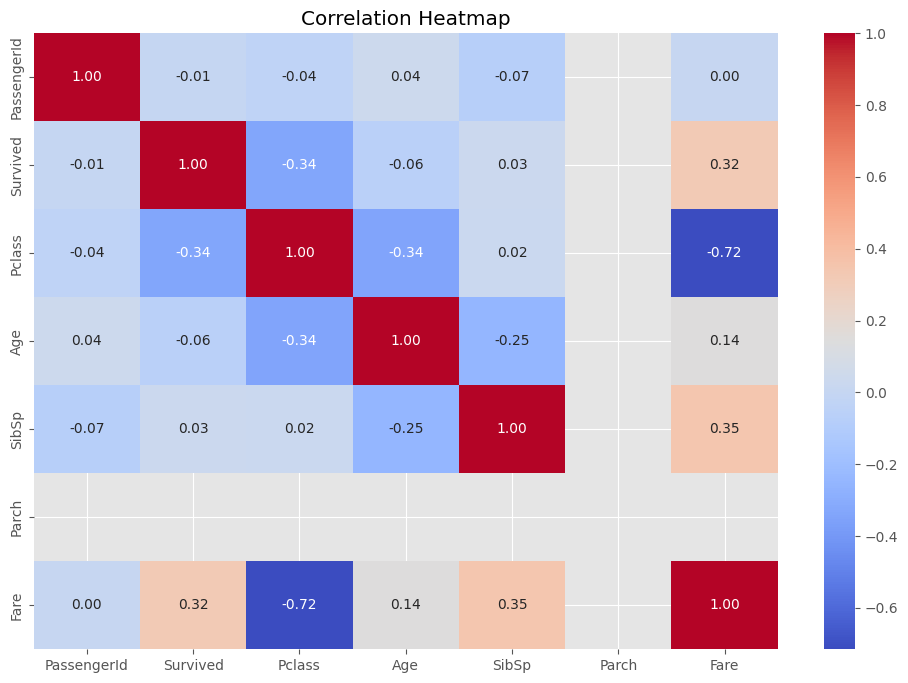

In [8]:
# Select only numeric columns
numeric_df = features_df.select_dtypes(include=["number"])

# Create the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap shows the correlation between numerical variables. Most variables have weak correlations, while some features such as Fare and Pclass show noticeable relationships. This visualization helps identify important patterns before building Machine Learning models.

## Distribution of Age

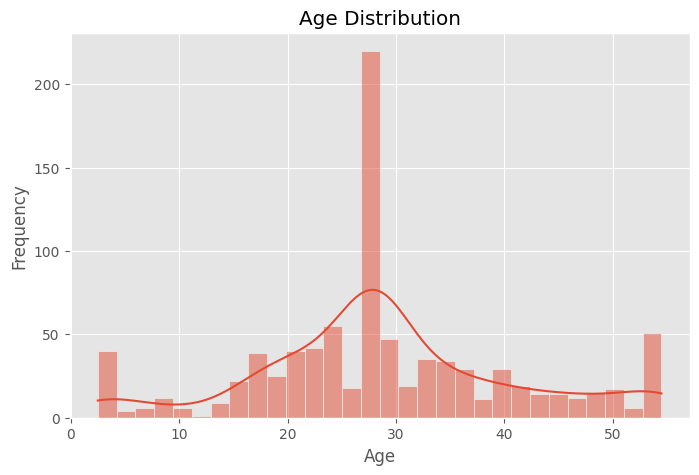

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(features_df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

Most passengers were young adults. The distribution is slightly right-skewed, indicating fewer elderly passengers compared to younger age groups.

## Distribution of Fare

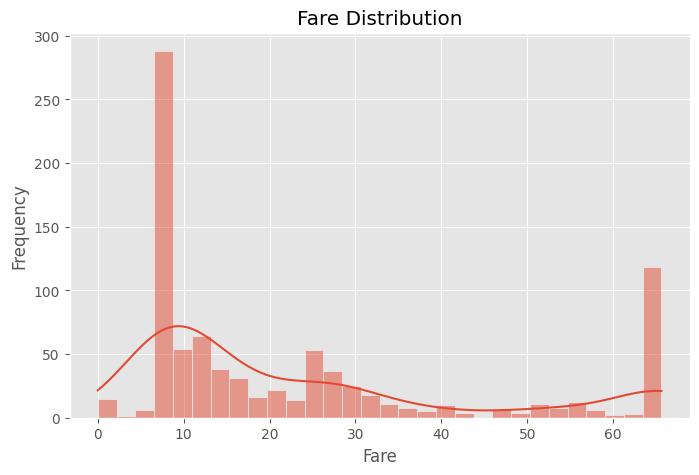

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(features_df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

### Observation

Most passengers paid relatively low fares, while a small number paid much higher fares. This creates a right-skewed distribution.

## Export Feature-Engineered Dataset

In [11]:
from pathlib import Path

output_path = Path.cwd() / "features_v1.csv"

features_df.to_csv(output_path, index=False)

print("Feature-engineered dataset exported successfully!")
print("Saved to:", output_path)

Feature-engineered dataset exported successfully!
Saved to: d:\ProSensia-AI-ML-Internship\Day 2\features_v1.csv


## Conclusion

In this notebook, Feature Engineering and Exploratory Data Analysis (EDA) were performed on the cleaned Titanic dataset.

Tasks completed:
- Loaded the cleaned dataset
- Verified dataset structure
- Checked for datetime columns
- Applied One-Hot Encoding to categorical variables
- Created a correlation heatmap
- Generated two distribution plots
- Exported the feature-engineered dataset as `features_v1.csv`

These preprocessing and visualization steps improve data understanding and prepare the dataset for future Machine Learning tasks.